# Exploratory Data Analysis + Feature Engineering + Preprocessing 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## add more imports as needed.

In [5]:
# Load in all training datasets + water quality dataset

water_quality_df = pd.read_csv("data/water_quality_training_dataset.csv")
terraclimate_df = pd.read_csv("data/terraclimate_features_training.csv")
nasadem_df = pd.read_csv("data/nasadem_features_training.csv")
modisVI_df = pd.read_csv("data/modisVI_features_training.csv")
modisLST_df = pd.read_csv("data/modisLST_features_training.csv")
landsat_df = pd.read_csv("data/landsat_features_training.csv")
jrc_df = pd.read_csv("data/jrc_features_training.csv")
isda_df = pd.read_csv("data/iSDA_features_training.csv")
hydrosheds_df = pd.read_csv("data/hydrosheds_features_training.csv")
era5_df = pd.read_csv("data/era5_features_training.csv")
chirps_df = pd.read_csv("data/chirps_features_training.csv")

In [6]:
## Join all features into a single Pandas DataFrame. (function from Benchmark Notebook)

# Combine two datasets vertically (along columns) using pandas concat function.
def combine_ten_datasets(d1,d2,d3,d4, d5, d6, d7, d8, d9, d10, d11):
    '''
    Returns a  vertically concatenated dataset.
    Attributes:
    dataset1 - Dataset 1 to be combined 
    dataset2 - Dataset 2 to be combined
    '''
    
    data = pd.concat([d1,d2,d3, d4, d5, d6, d7, d8, d9, d10, d11], axis=1)
    data = data.loc[:, ~data.columns.duplicated()]
    return data

In [7]:
wq_df = combine_ten_datasets(water_quality_df,
                             terraclimate_df,
                             nasadem_df,
                             modisVI_df,
                             modisLST_df,
                             landsat_df,
                             jrc_df,
                             isda_df, 
                             hydrosheds_df,
                             era5_df,
                             chirps_df)

wq_df.head()

,Latitude,Longitude,Sample Date,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus,pet,Unnamed: 0,elevation,EVI_median,...,phosphorous_mean,phosphorous_median,flow_accumulation,skin_temperature_median,soil_temperature_level_1_median,temperature_2m_median,total_evaporation_sum_median,total_precipitation_sum_median,volumetric_soil_water_layer_1_median,precipitation
0,-28.760833,17.730278,02-01-2011,128.912,555.0,10.0,174.2,0,167.155040,241.0,...,22.926434,23.0,4.131443e+06,307.919884,307.833471,300.198610,-0.000085,0.000001,0.008799,0.488024
1,-26.861111,28.884722,03-01-2011,74.720,162.9,163.0,124.1,1,1521.251493,4643.0,...,21.057342,21.0,1.162031e+04,293.665109,294.393847,292.444443,-0.004103,0.007830,0.458929,97.342756
2,-26.450000,28.085833,03-01-2011,89.254,573.0,80.0,127.5,2,1471.379902,3984.0,...,20.680648,21.0,1.000000e+00,293.972931,294.725525,292.828033,-0.004010,0.006964,0.393498,96.911494
3,-27.671111,27.236944,03-01-2011,82.000,203.6,101.0,129.7,3,1342.659998,2217.0,...,22.007566,22.0,1.878500e+04,294.280160,295.166729,293.509254,-0.003895,0.007228,0.409018,102.307634
4,-27.356667,27.286389,03-01-2011,56.100,145.1,151.0,129.2,4,1355.983661,4136.0,...,20.045393,20.0,4.778000e+03,294.414705,295.304085,293.890963,-0.003909,0.004980,0.437815,96.513882


In [8]:
wq_df.columns

Index(['Latitude', 'Longitude', 'Sample Date', 'Total Alkalinity',
       'Electrical Conductance', 'Dissolved Reactive Phosphorus', 'pet',
       'Unnamed: 0', 'elevation', 'EVI_median', 'NDVI_median',
       'Land Surface Temperature', 'nir', 'green', 'swir16', 'swir22', 'NDMI',
       'MNDWI', 'occurrence', 'seasonality', 'cec_mean', 'cec_median',
       'clay_mean', 'clay_median', 'pH_mean', 'pH_median', 'phosphorous_mean',
       'phosphorous_median', 'flow_accumulation', 'skin_temperature_median',
       'soil_temperature_level_1_median', 'temperature_2m_median',
       'total_evaporation_sum_median', 'total_precipitation_sum_median',
       'volumetric_soil_water_layer_1_median', 'precipitation'],
      dtype='object')

In [9]:
# Drop irrelevant columns and mean columns for data that has the same but with median since median is more robust to outliers.

wq_df = wq_df.drop(columns=['Unnamed: 0', 'cec_mean', 'clay_mean', 'pH_mean', 'phosphorous_mean'])
wq_df.columns

Index(['Latitude', 'Longitude', 'Sample Date', 'Total Alkalinity',
       'Electrical Conductance', 'Dissolved Reactive Phosphorus', 'pet',
       'elevation', 'EVI_median', 'NDVI_median', 'Land Surface Temperature',
       'nir', 'green', 'swir16', 'swir22', 'NDMI', 'MNDWI', 'occurrence',
       'seasonality', 'cec_median', 'clay_median', 'pH_median',
       'phosphorous_median', 'flow_accumulation', 'skin_temperature_median',
       'soil_temperature_level_1_median', 'temperature_2m_median',
       'total_evaporation_sum_median', 'total_precipitation_sum_median',
       'volumetric_soil_water_layer_1_median', 'precipitation'],
      dtype='object')

In [10]:
## remove _median ending from columns by renaming

wq_df = wq_df.rename(columns={'EVI_median': 'EVI',
                      'NDVI_median': 'NDVI',
                      'cec_median': 'cec',
                      'clay_median': 'clay',
                      'pH_median': 'pH',
                      'phosphorous_median': 'phosphorous',
                      'skin_temperature_median': 'skin_temperature',
                      'soil_temperature_level_1_median': 'soil_temperature',
                      'temperature_2m_median': 'temperature_2m',
                      'total_evaporation_sum_median': 'total_evaporation_sum',
                      'total_precipitation_sum_median': 'total_precipitation_sum',
                      'volumetric_soil_water_layer_1_median': 'volumetric_soil_water',
                      })

wq_df.head()

,Latitude,Longitude,Sample Date,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus,pet,elevation,EVI,NDVI,...,pH,phosphorous,flow_accumulation,skin_temperature,soil_temperature,temperature_2m,total_evaporation_sum,total_precipitation_sum,volumetric_soil_water,precipitation
0,-28.760833,17.730278,02-01-2011,128.912,555.0,10.0,174.2,167.155040,241.0,636.0,...,75.0,23.0,4.131443e+06,307.919884,307.833471,300.198610,-0.000085,0.000001,0.008799,0.488024
1,-26.861111,28.884722,03-01-2011,74.720,162.9,163.0,124.1,1521.251493,4643.0,7656.0,...,65.0,21.0,1.162031e+04,293.665109,294.393847,292.444443,-0.004103,0.007830,0.458929,97.342756
2,-26.450000,28.085833,03-01-2011,89.254,573.0,80.0,127.5,1471.379902,3984.0,6276.0,...,64.0,21.0,1.000000e+00,293.972931,294.725525,292.828033,-0.004010,0.006964,0.393498,96.911494
3,-27.671111,27.236944,03-01-2011,82.000,203.6,101.0,129.7,1342.659998,2217.0,3957.0,...,65.0,22.0,1.878500e+04,294.280160,295.166729,293.509254,-0.003895,0.007228,0.409018,102.307634
4,-27.356667,27.286389,03-01-2011,56.100,145.1,151.0,129.2,1355.983661,4136.0,7396.0,...,64.0,20.0,4.778000e+03,294.414705,295.304085,293.890963,-0.003909,0.004980,0.437815,96.513882


### Exploratory Data Analysis

Things to check:
+ data skew
+ range
+ correlation heatmap
+ histograms
+ missing / Nan values
+ min, max, scaling needs

In [11]:
wq_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9319 entries, 0 to 9318
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Latitude                       9319 non-null   float64
 1   Longitude                      9319 non-null   float64
 2   Sample Date                    9319 non-null   object 
 3   Total Alkalinity               9319 non-null   float64
 4   Electrical Conductance         9319 non-null   float64
 5   Dissolved Reactive Phosphorus  9319 non-null   float64
 6   pet                            9319 non-null   float64
 7   elevation                      9319 non-null   float64
 8   EVI                            9319 non-null   float64
 9   NDVI                           9319 non-null   float64
 10  Land Surface Temperature       9319 non-null   float64
 11  nir                            8234 non-null   float64
 12  green                          8234 non-null   f

It looks like the columns: nir, green, swir16, swir22, NDMI, MNDWI, occurence, seasonality, volumetric_soil_water and precipitation all have missing values.

Occurence and seasonality are more concerning since more than half of all values are missing.

In [12]:
wq_df.describe(include='all')

,Latitude,Longitude,Sample Date,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus,pet,elevation,EVI,NDVI,...,pH,phosphorous,flow_accumulation,skin_temperature,soil_temperature,temperature_2m,total_evaporation_sum,total_precipitation_sum,volumetric_soil_water,precipitation
count,9319.000000,9319.000000,9319,9319.000000,9319.000000,9319.000000,9319.000000,9319.000000,9319.000000,9319.000000,...,9319.000000,9319.000000,9.319000e+03,9023.000000,9023.000000,9023.000000,9023.000000,9023.000000,9.023000e+03,9267.000000
unique,NaN,NaN,1364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,08-01-2014,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,-28.474988,26.868414,NaN,119.108208,485.004146,43.525338,175.166082,912.703348,2458.096952,4493.927943,...,64.729370,22.490718,8.329879e+04,291.973843,292.569446,290.785245,-0.001607,0.000469,2.097844e-01,19.595726
std,2.760282,3.535164,NaN,74.692591,341.937736,50.980194,29.469867,514.992034,1057.067224,1560.694366,...,4.057373,2.627250,3.694290e+05,6.014758,5.881180,5.005348,0.001262,0.001022,9.617623e-02,24.046827
min,-34.405833,17.730278,NaN,4.800000,15.120000,5.000000,52.700000,5.545029,-402.000000,-884.000000,...,55.000000,18.000000,1.000000e+00,273.873395,273.756044,275.238318,-0.005334,0.000000,-8.756881e-21,0.000000
25%,-30.160091,26.126667,NaN,55.811000,207.050000,10.000000,156.100000,388.516336,1599.250000,3167.750000,...,62.000000,20.000000,5.820909e+02,287.527561,288.175237,287.068002,-0.002501,0.000001,1.351469e-01,0.000000
50%,-28.058889,27.409060,NaN,113.300000,402.000000,20.000000,172.500000,1083.049521,2305.500000,4432.000000,...,65.000000,22.000000,7.620524e+03,292.579847,293.172668,291.409486,-0.001318,0.000031,1.948907e-01,10.172029
75%,-26.861111,29.245556,NaN,170.230000,693.000000,48.000000,193.100000,1320.711972,3126.000000,5677.750000,...,67.000000,25.000000,3.759100e+04,296.313968,296.853333,294.530824,-0.000504,0.000434,2.792343e-01,30.137603


Data values have huge ranges, for SVM it will have to be scaled appropriately using StandardScaler().

In [14]:
wq_df.shape

(9319, 31)

Since occurrence and seasonality are missing over 50% of their values, they will be dropped entirely since no valuable patterns are likely to be formed from them and it might introduce bias if that many values are imputed.

In [15]:
wq_df = wq_df.drop(columns=['occurrence', 'seasonality'])
wq_df.columns

Index(['Latitude', 'Longitude', 'Sample Date', 'Total Alkalinity',
       'Electrical Conductance', 'Dissolved Reactive Phosphorus', 'pet',
       'elevation', 'EVI', 'NDVI', 'Land Surface Temperature', 'nir', 'green',
       'swir16', 'swir22', 'NDMI', 'MNDWI', 'cec', 'clay', 'pH', 'phosphorous',
       'flow_accumulation', 'skin_temperature', 'soil_temperature',
       'temperature_2m', 'total_evaporation_sum', 'total_precipitation_sum',
       'volumetric_soil_water', 'precipitation'],
      dtype='object')

Since some models can handle Nan values, but some cannot, I will test the ones that can handle Nan values with both imputed and non-imputed data to see where it performs better.

<Axes: >

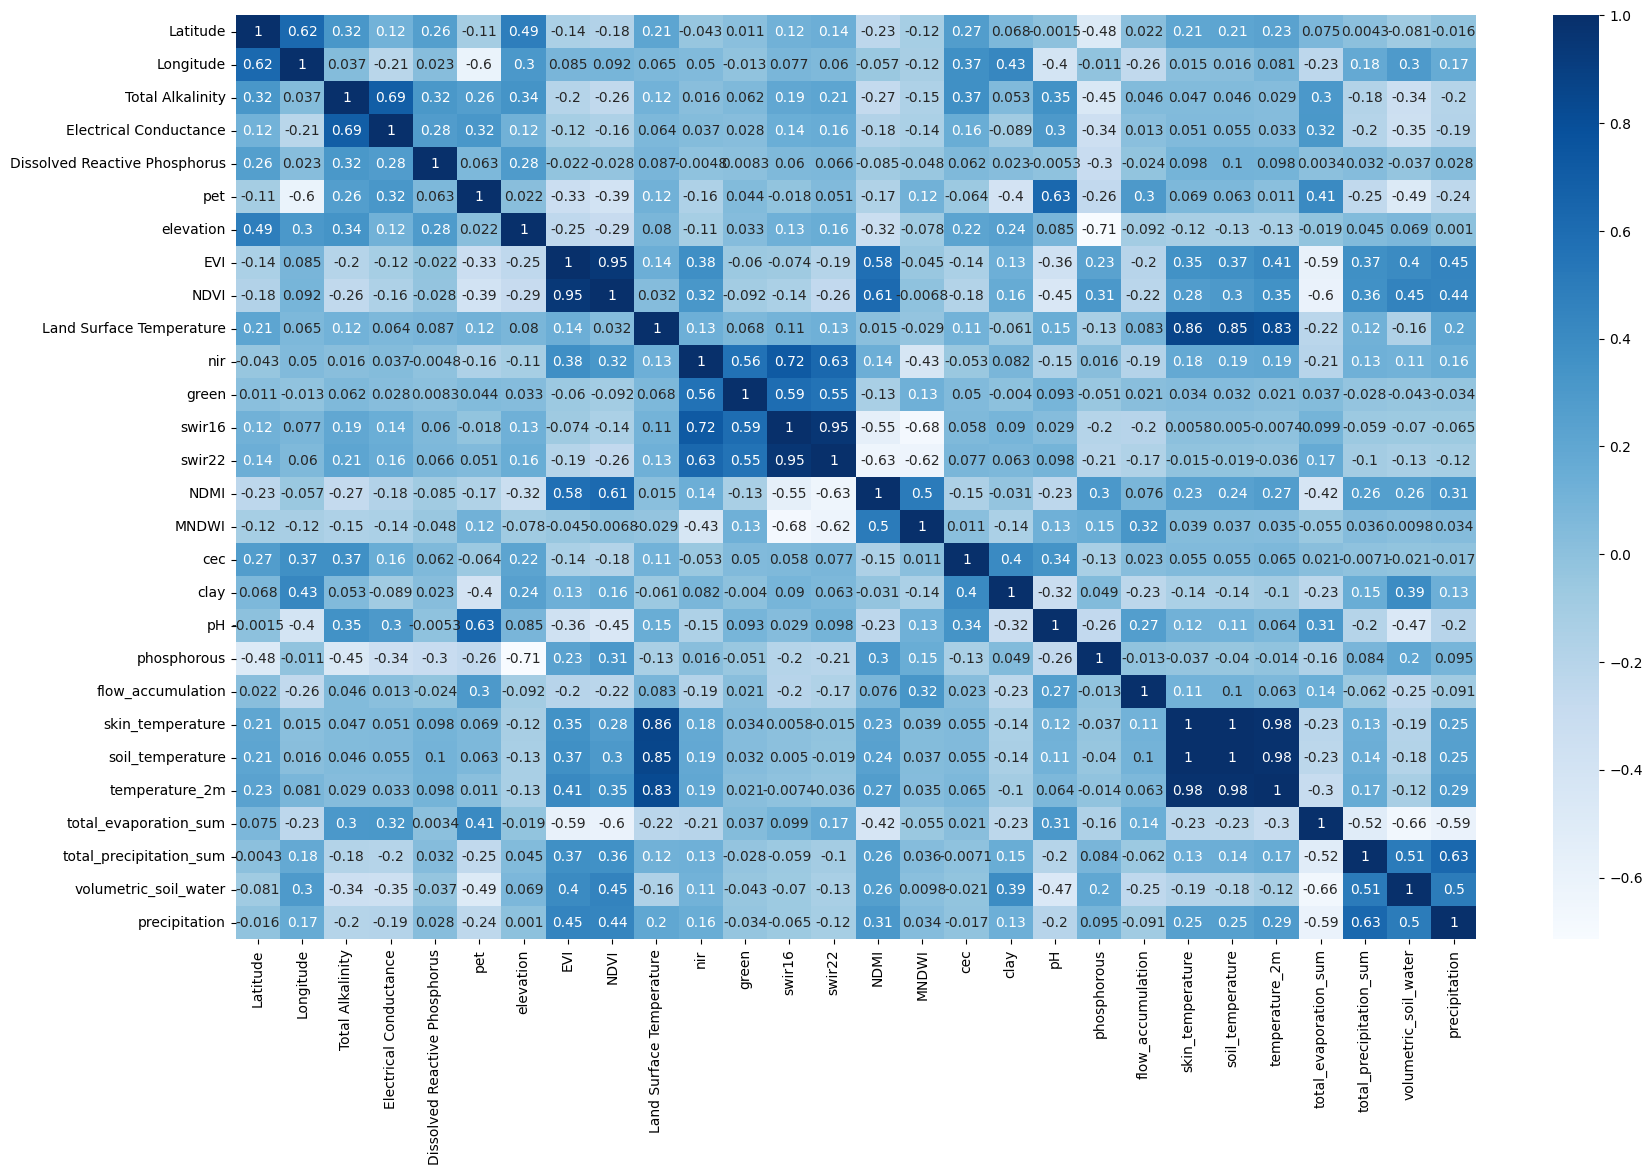

In [18]:
## Plot correlation heatmap with Seaborn.

import seaborn as sns

drop_date_df = wq_df.drop(columns=['Sample Date'])
plt.figure(figsize=(20, 12))
sns.heatmap(drop_date_df.corr(), annot=True, cmap=plt.cm.Blues)

The temperature features: skin_temperature, soil_temperature, temperature_2m are quite highly correlated, this might introduce redundancy, lets see if its dropped during feature selection. It also looks like the target variables are quite well correlated to eachother, making RegressionChaining a promising choice to maximise predictive performance.

In [19]:
# Get columns for histogram plotting

drop_date_df.columns

Index(['Latitude', 'Longitude', 'Total Alkalinity', 'Electrical Conductance',
       'Dissolved Reactive Phosphorus', 'pet', 'elevation', 'EVI', 'NDVI',
       'Land Surface Temperature', 'nir', 'green', 'swir16', 'swir22', 'NDMI',
       'MNDWI', 'cec', 'clay', 'pH', 'phosphorous', 'flow_accumulation',
       'skin_temperature', 'soil_temperature', 'temperature_2m',
       'total_evaporation_sum', 'total_precipitation_sum',
       'volumetric_soil_water', 'precipitation'],
      dtype='object')

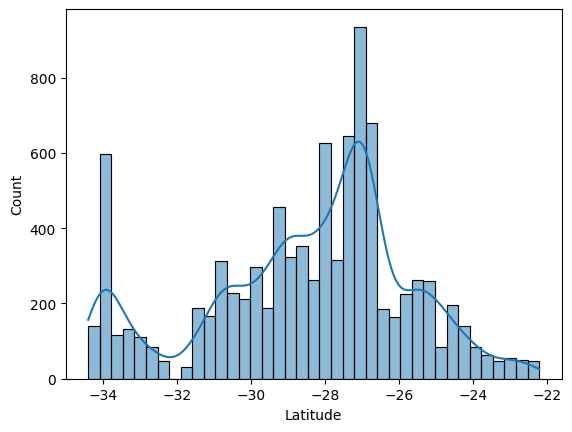

<Figure size 200x100 with 0 Axes>

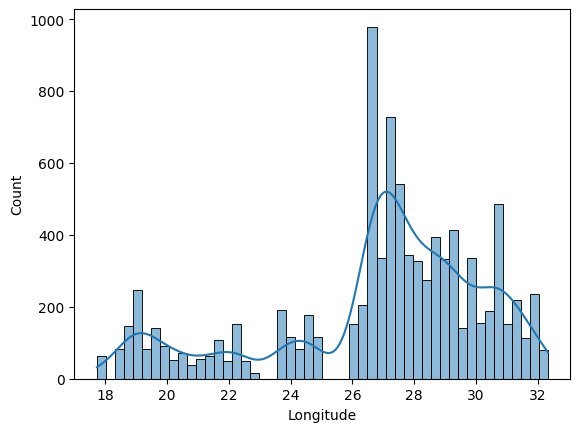

<Figure size 200x100 with 0 Axes>

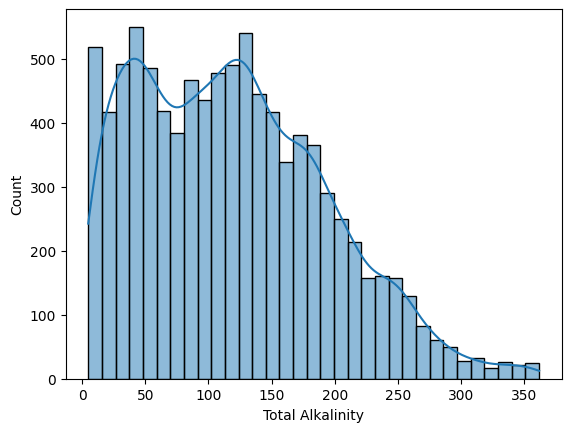

<Figure size 200x100 with 0 Axes>

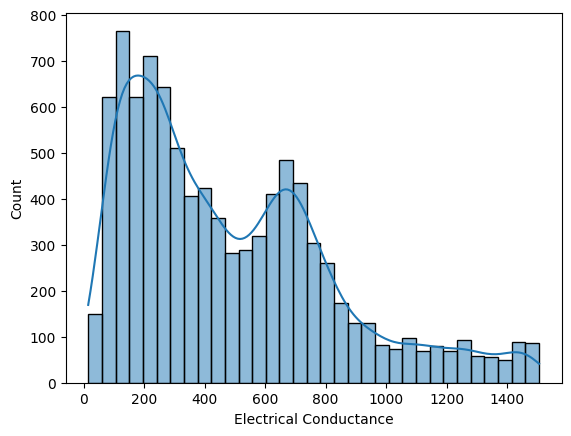

<Figure size 200x100 with 0 Axes>

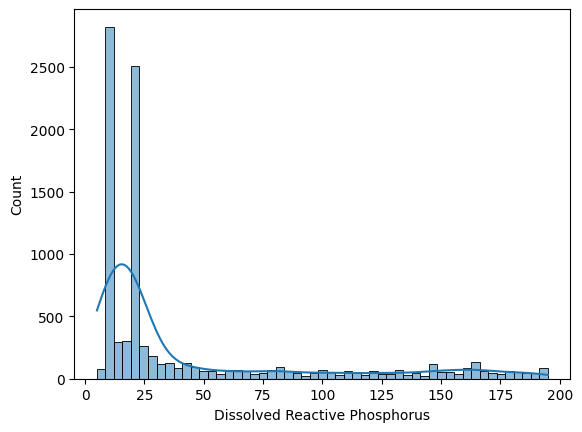

<Figure size 200x100 with 0 Axes>

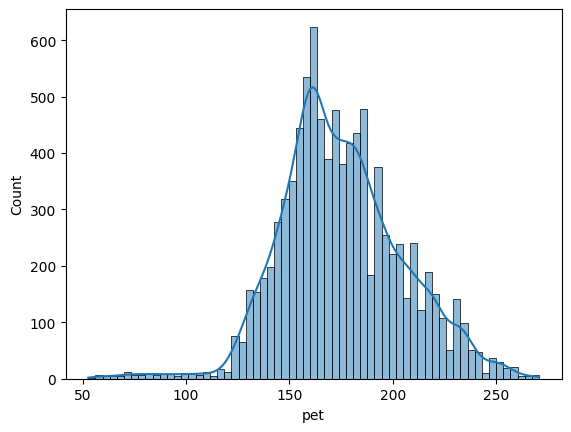

<Figure size 200x100 with 0 Axes>

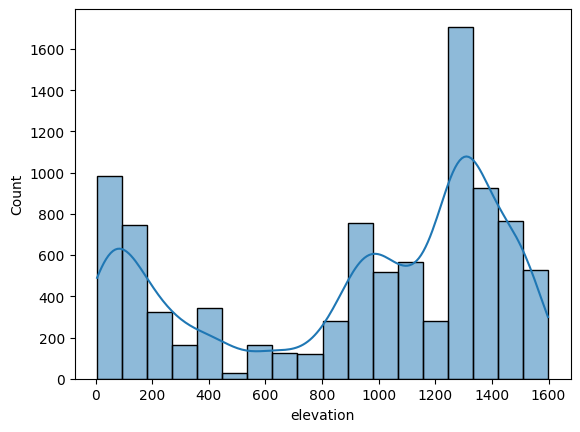

<Figure size 200x100 with 0 Axes>

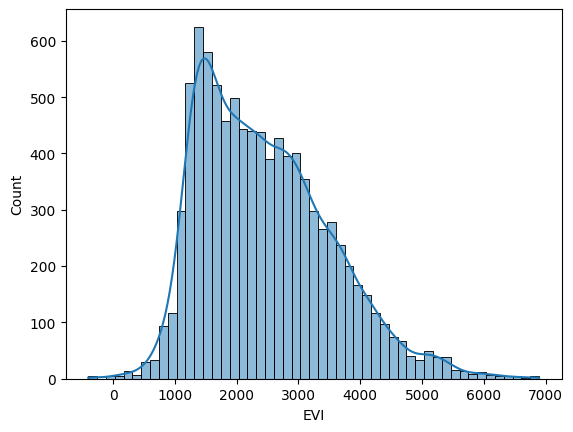

<Figure size 200x100 with 0 Axes>

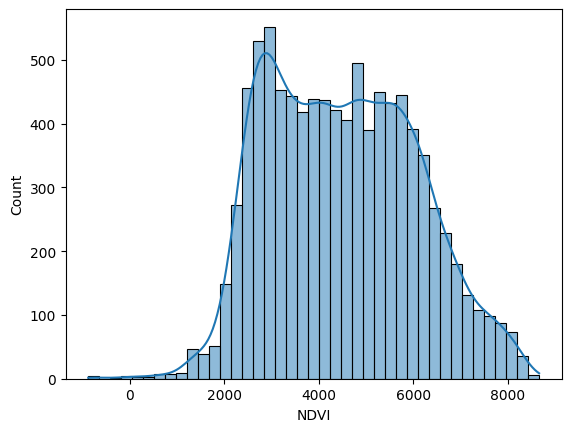

<Figure size 200x100 with 0 Axes>

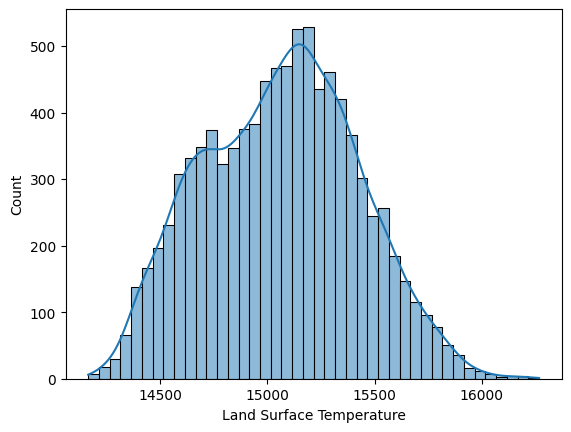

<Figure size 200x100 with 0 Axes>

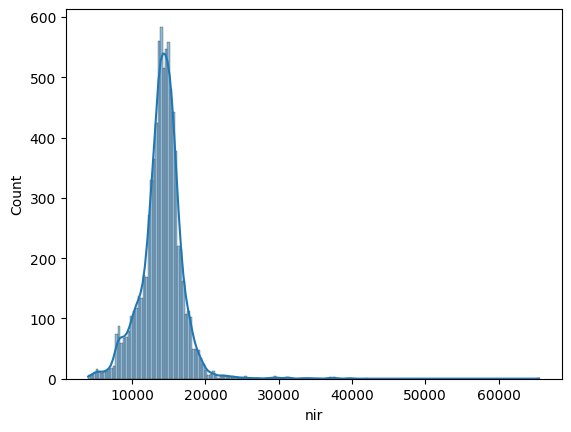

<Figure size 200x100 with 0 Axes>

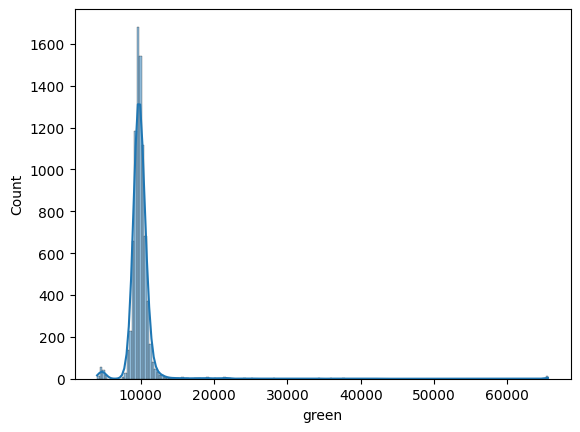

<Figure size 200x100 with 0 Axes>

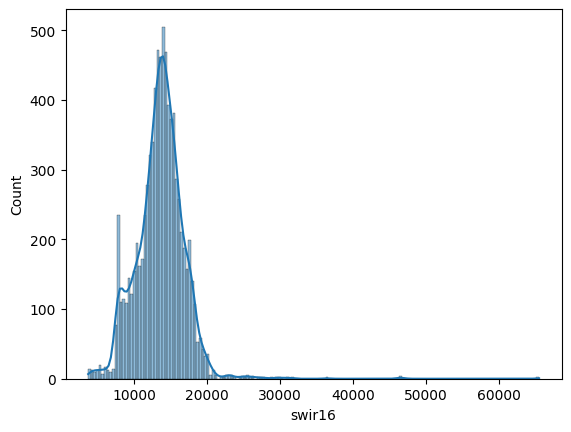

<Figure size 200x100 with 0 Axes>

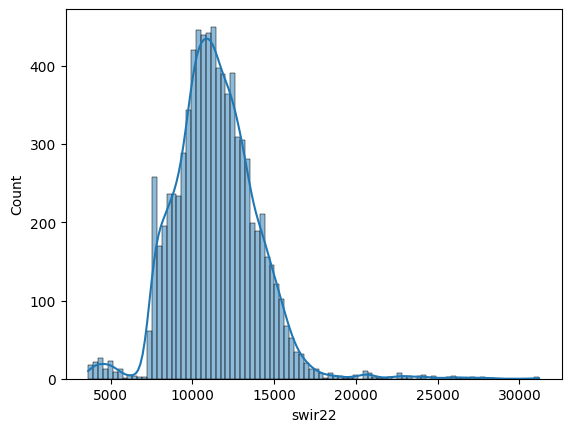

<Figure size 200x100 with 0 Axes>

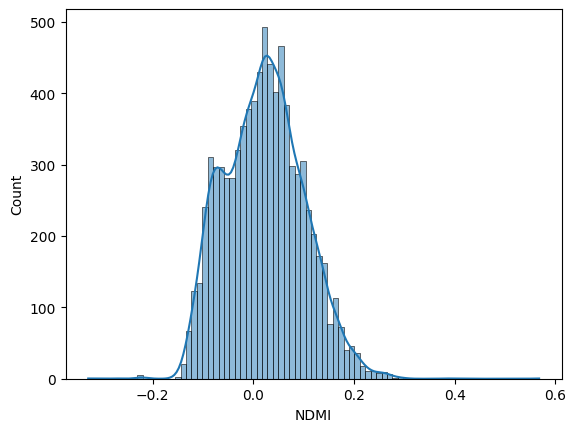

<Figure size 200x100 with 0 Axes>

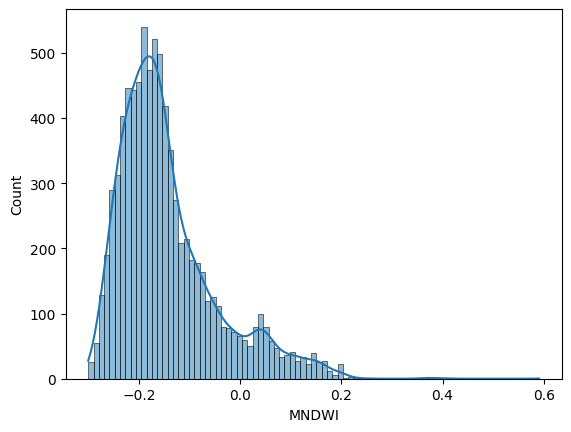

<Figure size 200x100 with 0 Axes>

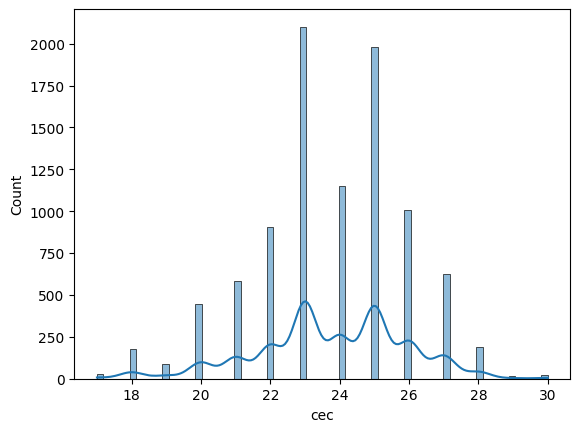

<Figure size 200x100 with 0 Axes>

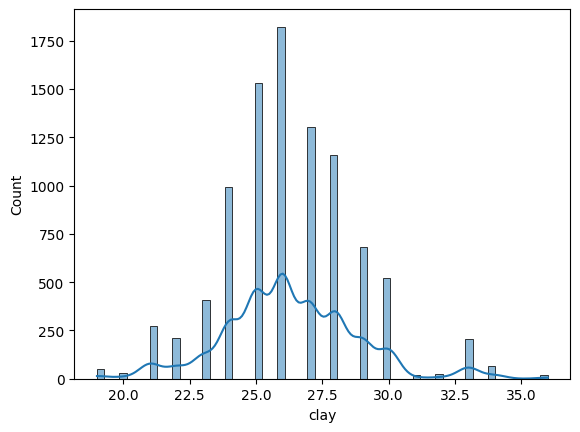

<Figure size 200x100 with 0 Axes>

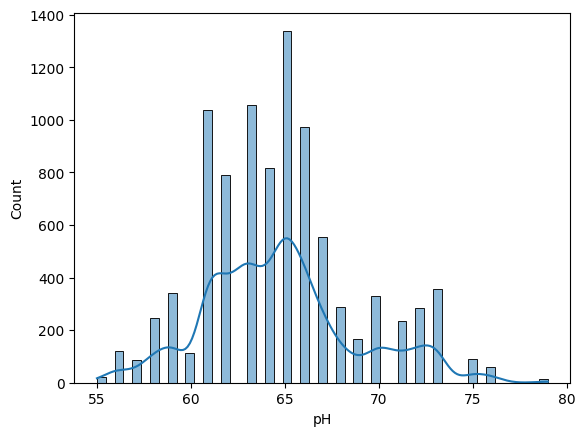

<Figure size 200x100 with 0 Axes>

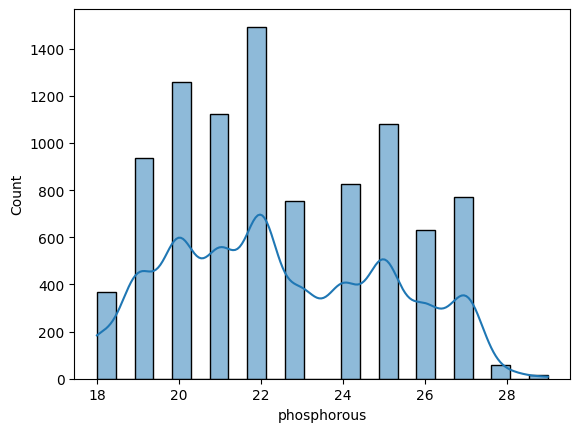

<Figure size 200x100 with 0 Axes>

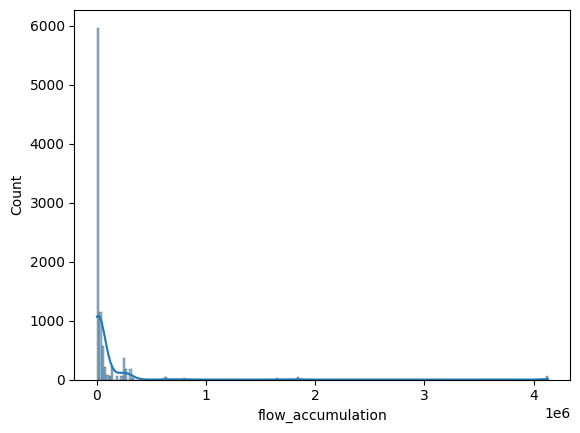

<Figure size 200x100 with 0 Axes>

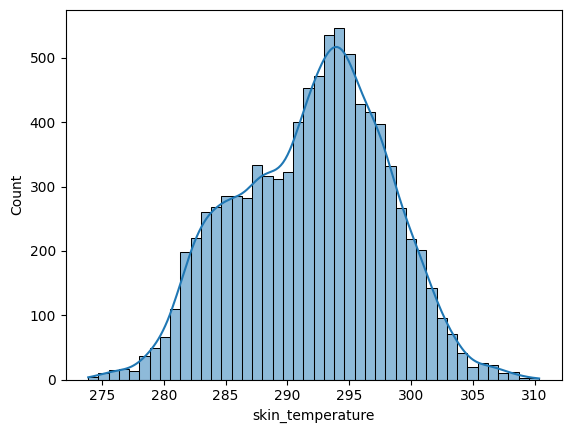

<Figure size 200x100 with 0 Axes>

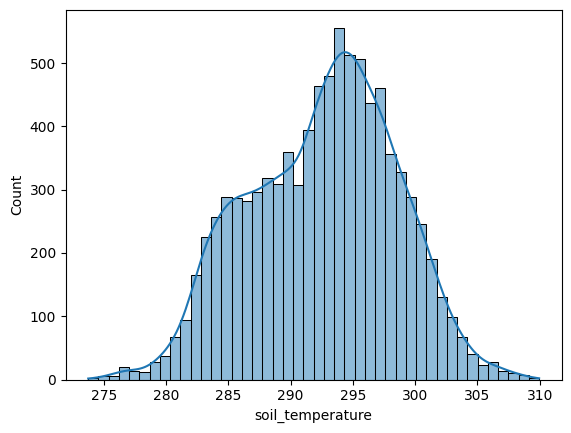

<Figure size 200x100 with 0 Axes>

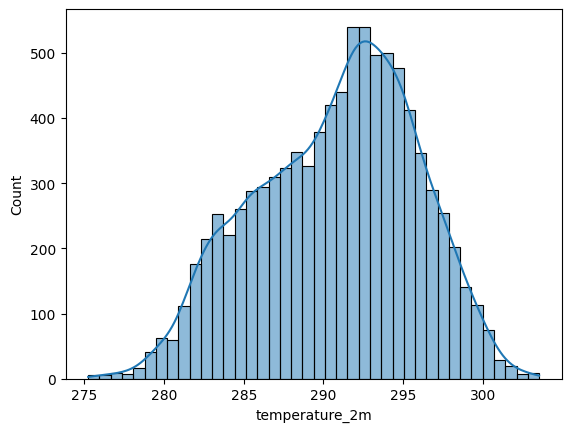

<Figure size 200x100 with 0 Axes>

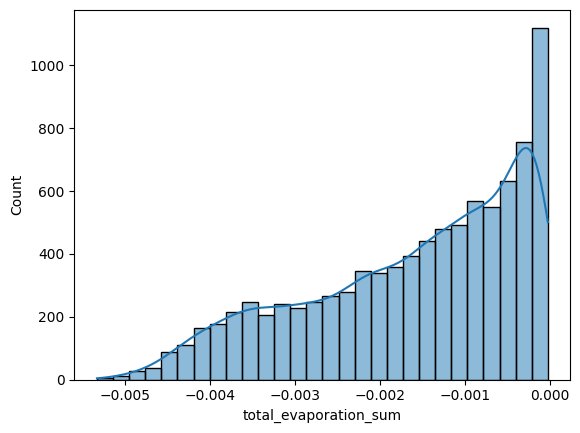

<Figure size 200x100 with 0 Axes>

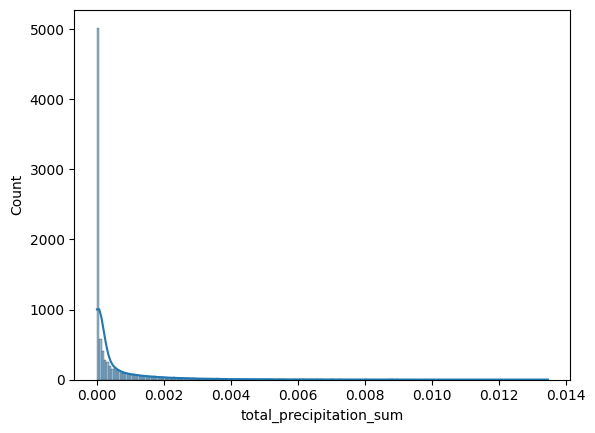

<Figure size 200x100 with 0 Axes>

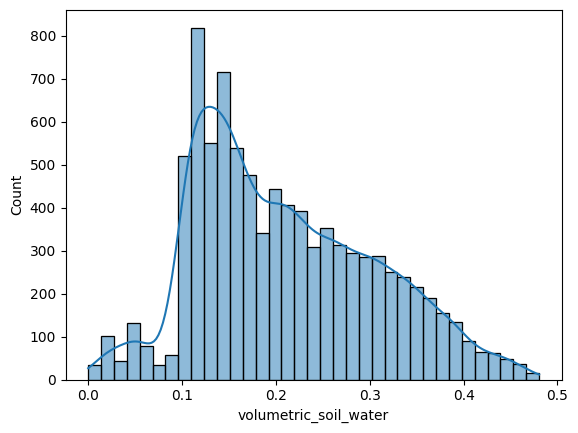

<Figure size 200x100 with 0 Axes>

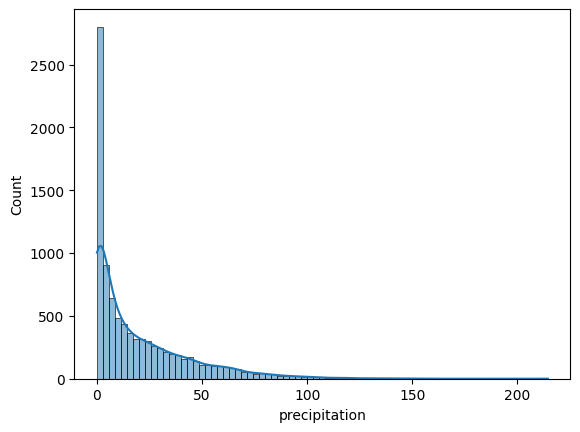

<Figure size 200x100 with 0 Axes>

In [28]:
## plot histograms for each feature along with target variables, as well combined hist of targets to see correlation in distributions

features = ['Latitude', 'Longitude', 'Total Alkalinity', 'Electrical Conductance',
       'Dissolved Reactive Phosphorus', 'pet', 'elevation', 'EVI', 'NDVI',
       'Land Surface Temperature', 'nir', 'green', 'swir16', 'swir22', 'NDMI',
       'MNDWI', 'cec', 'clay', 'pH', 'phosphorous', 'flow_accumulation',
       'skin_temperature', 'soil_temperature', 'temperature_2m',
       'total_evaporation_sum', 'total_precipitation_sum',
       'volumetric_soil_water', 'precipitation']

for feat in features:
    sns.histplot(drop_date_df[feat], kde=True)
    plt.figure(figsize=(2, 1))
    plt.show()